In [ ]:
import pandas as pd

daily_df = pd.read_csv('/content/Volve daily production data.csv', encoding='latin-1', skiprows=[1])

For Task 1.1

In [ ]:
daily_df.head(2)
# daily_df.describe()
print("total days:", len (daily_df))

total days: 15633


In [ ]:

active_df = daily_df[daily_df['ON_STREAM_HRS'] > 0]
# active_df.describe()
print("active days:", len (active_df))

active days: 13397


In [ ]:
bad_sensor_rows = daily_df[(daily_df['ON_STREAM_HRS'] > 20 ) & (daily_df['AVG_WHP_P'] > 0) & (daily_df['BORE_OIL_VOL'] == 0)]
print("number of bad_sensor_rows", len(bad_sensor_rows))

number of bad_sensor_rows 0


In [ ]:

clean_df = active_df.drop(bad_sensor_rows.index)
print('clean days', len(clean_df))

clean days 13397


In [ ]:
True_shut_in_days = len(daily_df) - len(clean_df)

In [ ]:
print("In summary ",
      "\ntotal days:", len (daily_df),"days",
      "\nactive days:", len (active_df),"days",
      "\nnumber of bad_sensor_rows:", len(bad_sensor_rows),"days",
      '\nclean days:', len(clean_df),"days",

      "\nThe final count of the true shut-in days is", True_shut_in_days, "days"
)

In summary  
total days: 15633 days 
active days: 13397 days 
number of bad_sensor_rows: 0 days 
clean days: 13397 days 
The final count of the true shut-in days is 2236 days


For Task 1.2

In [ ]:
monthly_df = pd.read_csv('/content/Volve monthly production data.csv', encoding='latin-1', skiprows=[1])

In [ ]:
monthly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Wellbore name  526 non-null    object 
 1   NPDCode        526 non-null    int64  
 2   Year           526 non-null    int64  
 3   Month          526 non-null    int64  
 4   On Stream      515 non-null    float64
 5   Oil            311 non-null    object 
 6   Gas            311 non-null    object 
 7   Water          311 non-null    object 
 8   GI             0 non-null      float64
 9   WI             201 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 41.2+ KB


In [ ]:
from numpy._core.numeric import astype
import pandas as pd
import numpy as np

def clean_well_data(df):

  # 1. Sanitize text input directly
  text_cols = df.select_dtypes(include=['object']).columns
  for col in text_cols:
    df[col] = df[col].str.strip()

  # 2. Replace Null strings with mathematically sound missing values
  df = df.replace(["", "null", "NULL", "nan"], np.nan)

  # 3. Check for 0 production vs missing sensor
  if 'On Stream' in df.columns and 'Oil' in df.columns:
    shut_in_mask = df['On Stream'] == 0
    df.loc[shut_in_mask, 'Oil'] = df.loc[shut_in_mask, 'Oil'].fillna(0)

  # 4. Parse dates dynamically and assign to a new column
  if 'Year' in df.columns and 'Month' in df.columns:
    df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

  return df

In [ ]:
clean_df = clean_well_data(monthly_df)
clean_df.info()
clean_df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Wellbore name  526 non-null    object        
 1   NPDCode        526 non-null    int64         
 2   Year           526 non-null    int64         
 3   Month          526 non-null    int64         
 4   On Stream      515 non-null    float64       
 5   Oil            321 non-null    object        
 6   Gas            311 non-null    object        
 7   Water          311 non-null    object        
 8   GI             0 non-null      float64       
 9   WI             201 non-null    object        
 10  Date           526 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 45.3+ KB


,Wellbore name,NPDCode,Year,Month,On Stream,Oil,Gas,Water,GI,WI,Date
0,15/9-F-1 C,7405,2014,4,228.0,"11,142","1,597,937",0,NaN,NaN,2014-04-01
1,15/9-F-1 C,7405,2014,5,734.0,"24,902","3,496,230",783,NaN,NaN,2014-05-01
2,15/9-F-1 C,7405,2014,6,706.0,"19,618","2,886,662","2,068",NaN,NaN,2014-06-01


Task 1.3 Handling the dead sensor window

In [ ]:
import pandas as pd
daily_df = pd.read_csv('/content/Volve daily production data.csv', encoding='latin-1', skiprows=[1])
# Clean the daily dataset using our custom function
clean_daily_df = clean_well_data(daily_df)

# 1. Force the columns to be numeric, turning any leftover text into NaN
clean_daily_df['BORE_OIL_VOL'] = pd.to_numeric(clean_daily_df['BORE_OIL_VOL'], errors='coerce')
clean_daily_df['AVG_DOWNHOLE_PRESSURE'] = pd.to_numeric(clean_daily_df['AVG_DOWNHOLE_PRESSURE'], errors='coerce')

# 2. Re-create our masks
dead_mask = (clean_daily_df['BORE_OIL_VOL'] > 10) & (clean_daily_df['AVG_DOWNHOLE_PRESSURE'].fillna(0) == 0)
healthy_mask = (clean_daily_df['BORE_OIL_VOL'] > 10) & (clean_daily_df['AVG_DOWNHOLE_PRESSURE'] > 0)

In [ ]:
from sklearn.linear_model import LinearRegression


# i used 2D for avg_whp_p and 1D for avg_downhole_pressure

# 3. i Apply the mask to extract only the healthy rows into a new dataframe
healthy_df = clean_daily_df[healthy_mask]

# 4. Define our X (predictor) and y (target)
X_train = healthy_df[['AVG_WHP_P']]
y_train = healthy_df['AVG_DOWNHOLE_PRESSURE']

# 5. Train the physics-informed model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# I the process i solving this an error that came up means that on some of the days where the downhole sensor was dead, the wellhead sensor was also missing or broken, leaving a blank NaN value.
# to adjust that i will force evey AVG_WHP_P to be numeric so any hidden text can be true NaN

clean_daily_df['AVG_WHP_P'] = pd.to_numeric(clean_daily_df['AVG_WHP_P'], errors='coerce')

dead_mask = (
    (clean_daily_df['BORE_OIL_VOL'] > 10) &
    (clean_daily_df['AVG_DOWNHOLE_PRESSURE'].fillna(0) == 0) &
    (clean_daily_df['AVG_WHP_P'].notna())
)

# 6. Re-extract the broken rows and their wellhead pressures
dead_df = clean_daily_df[dead_mask].copy()
X_dead = dead_df[['AVG_WHP_P']]

# 7. Generate the predictions
predicted_pressures = model.predict(X_dead)

# PLS NOTE when you run this cell a second time, the downhole pressures are no longer 0 or NaN—they are fixed! Because the data is already repaired, the mask finds 0 broken rows, leaving the model with nothing to predict.
# The fact that you got this specific error of 'found array with o samples' actually means my reconstruction code worked perfectly on the previous run. My dataframe is officially sanitized and ready for machine learning.
# To view the physics-informed formula remove the 'volve daily file' and run the entire cell just once.

# 8. Inject the predictions back into the main dataset
clean_daily_df.loc[dead_mask, 'AVG_DOWNHOLE_PRESSURE'] = predicted_pressures


#9. Extract the slope (m) and y-intercept (b)
m = model.coef_[0]
b = model.intercept_

#10. Print the final physics-informed formula
print(f"Downhole Pressure = ({m:.2f} * Wellhead Pressure) + {b:.2f}")


Downhole Pressure = (0.12 * Wellhead Pressure) + 234.94


PHASE 2: Physics Informed Feature Engineering with Pandas

Task 2.1 Tubing Hydraulics Pressure Drop

In [ ]:
clean_daily_df['TUBING_PRESSURE_DROP'] = clean_daily_df['AVG_DOWNHOLE_PRESSURE'] - clean_daily_df['AVG_WHP_P']
clean_daily_df.head(10)
# i am good to go i used the sanitization logic established in Phase 1 to avoid introducing mathematically corrupted or negative differentials into the feature matrix.

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE,TUBING_PRESSURE_DROP
0,08-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000,0.000,0.000,0.0,0,0,NaN,production,OP,NaN
1,09-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000,0.000,0.000,0.0,0,0,NaN,production,OP,NaN
2,10-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000,0.000,0.000,0.0,0,0,NaN,production,OP,NaN
3,11-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.376,...,33.098,10.480,33.072,0.0,0,0,NaN,production,OP,277.278
4,12-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.501,...,22.053,8.704,22.053,0.0,0,0,NaN,production,OP,281.448
5,13-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.535,...,27.503,9.423,16.163,0.0,0,0,NaN,production,OP,276.032
6,14-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.782,...,20.996,8.131,20.737,0.0,0,0,NaN,production,OP,282.786
7,15-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.858,...,13.918,8.498,12.182,0.0,0,0,NaN,production,OP,289.940
8,16-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.792,...,4.120,8.821,1.490,0.0,0,0,NaN,production,OP,299.672
9,17-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,304.335,...,21.434,8.854,18.795,0.0,0,0,NaN,production,OP,282.901


Task 2.2: Sub_surface pressure Draw down

In [ ]:
import numpy as np

# 1. Isolate buildup states
buildup_mask = (clean_daily_df['ON_STREAM_HRS'] == 0) & (clean_daily_df['AVG_DOWNHOLE_PRESSURE'] > 50)

# 2. Generate a step-function baseline
# First, i create the empty column and insert ONLY the buildup pressures
clean_daily_df['Static_Reservoir_Pressure_Proxy'] = np.nan
clean_daily_df.loc[buildup_mask, 'Static_Reservoir_Pressure_Proxy'] = clean_daily_df['AVG_DOWNHOLE_PRESSURE']

# i apply the forward-fill strictly within each unique wellbore because
# Backward-filling would apply future, lower pressures to the past, physically
# corrupting the data by ignoring this natural depletion.
clean_daily_df['Static_Reservoir_Pressure_Proxy'] = (
    clean_daily_df.groupby('NPD_WELL_BORE_NAME')['Static_Reservoir_Pressure_Proxy']
    .ffill()
)

# 3. Compute the proxy drawdown feature
clean_daily_df['Drawdown_Proxy'] = (
    clean_daily_df['Static_Reservoir_Pressure_Proxy'] - clean_daily_df['AVG_DOWNHOLE_PRESSURE']
)

clean_daily_df.head(10)


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE,TUBING_PRESSURE_DROP,Static_Reservoir_Pressure_Proxy,Drawdown_Proxy
0,08-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000,0.0,0,0,NaN,production,OP,NaN,NaN,NaN
1,09-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000,0.0,0,0,NaN,production,OP,NaN,NaN,NaN
2,10-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,0.000,0.0,0,0,NaN,production,OP,NaN,NaN,NaN
3,11-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.376,...,33.072,0.0,0,0,NaN,production,OP,277.278,310.376,0.0
4,12-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.501,...,22.053,0.0,0,0,NaN,production,OP,281.448,303.501,0.0
5,13-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.535,...,16.163,0.0,0,0,NaN,production,OP,276.032,303.535,0.0
6,14-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.782,...,20.737,0.0,0,0,NaN,production,OP,282.786,303.782,0.0
7,15-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.858,...,12.182,0.0,0,0,NaN,production,OP,289.940,303.858,0.0
8,16-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,303.792,...,1.490,0.0,0,0,NaN,production,OP,299.672,303.792,0.0
9,17-Apr-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,304.335,...,18.795,0.0,0,0,NaN,production,OP,282.901,304.335,0.0


Task 2.3: Time-Series Lagging & Transient Regime Capture

In [ ]:
import pandas as pd

clean_daily_df = clean_daily_df.sort_values(by=['NPD_WELL_BORE_NAME', 'DATEPRD'])
# 1. Create Time-Series Lag features for the Choke Size (T-1, T-3, T-7 days)
clean_daily_df['AVG_CHOKE_SIZE_P_Lag1'] = clean_daily_df.groupby('NPD_WELL_BORE_NAME')['AVG_CHOKE_SIZE_P'].shift(1)
clean_daily_df['AVG_CHOKE_SIZE_P_Lag3'] = clean_daily_df.groupby('NPD_WELL_BORE_NAME')['AVG_CHOKE_SIZE_P'].shift(3)
clean_daily_df['AVG_CHOKE_SIZE_P_Lag7'] = clean_daily_df.groupby('NPD_WELL_BORE_NAME')['AVG_CHOKE_SIZE_P'].shift(7)

# 2. Create the Choke Volatility Index (3-day rolling standard deviation)
#I use .transform() to apply the rolling math while keeping the dataframe structure intact
clean_daily_df['Choke_Volatility_Index'] = (
    clean_daily_df.groupby('NPD_WELL_BORE_NAME')['AVG_CHOKE_SIZE_P']
    .transform(lambda x: x.rolling(window=3, min_periods=1).std())
)
# i also fill the initial NaN volatility values with 0 (since no movement = 0 volatility)
clean_daily_df['Choke_Volatility_Index'] = clean_daily_df['Choke_Volatility_Index'].fillna(0)

clean_daily_df.head(10)

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,BORE_WI_VOL,FLOW_KIND,WELL_TYPE,TUBING_PRESSURE_DROP,Static_Reservoir_Pressure_Proxy,Drawdown_Proxy,AVG_CHOKE_SIZE_P_Lag1,AVG_CHOKE_SIZE_P_Lag3,AVG_CHOKE_SIZE_P_Lag7,Choke_Volatility_Index
358,01-Apr-15,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,6.46,211.300,...,NaN,production,OP,182.844,286.797,75.497,NaN,NaN,NaN,0.000000
724,01-Apr-16,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,24.00,224.568,...,NaN,production,OP,197.511,299.722,75.154,17.94654,NaN,NaN,26.038458
115,01-Aug-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,24.00,215.027,...,NaN,production,OP,171.356,313.871,98.844,54.77048,NaN,NaN,19.747076
480,01-Aug-15,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,24.00,231.570,...,NaN,production,OP,197.857,293.689,62.119,48.72132,17.94654,NaN,5.003661
237,01-Dec-14,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,13.50,255.410,...,NaN,production,OP,248.865,268.789,13.379,58.64993,54.77048,NaN,5.249959
602,01-Dec-15,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,24.00,219.293,...,NaN,production,OP,192.189,294.823,75.530,56.64421,48.72132,NaN,1.489968
299,01-Feb-15,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.00,265.351,...,NaN,production,OP,193.004,265.351,0.000,55.73845,58.64993,NaN,32.445240
664,01-Feb-16,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.00,285.146,...,NaN,production,OP,172.013,285.146,0.000,0.00000,56.64421,17.94654,32.180609
268,01-Jan-15,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,9.50,298.436,...,NaN,production,OP,192.409,309.332,10.896,0.00000,55.73845,54.77048,25.403412
633,01-Jan-16,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.00,296.916,...,NaN,production,OP,172.980,296.916,0.000,44.00000,0.00000,48.72132,25.403412


In [ ]:
# View the first 20 rows of the choke size and its new volatility index
clean_daily_df[['AVG_CHOKE_SIZE_P', 'Choke_Volatility_Index']].head(20)

,AVG_CHOKE_SIZE_P,Choke_Volatility_Index
0,1.00306,0.000000
1,0.97901,0.017006
2,0.54576,0.257361
3,1.21599,0.339871
4,3.08702,1.317065
5,1.96237,0.941866
6,0.00000,1.562339
7,31.14186,17.440895
8,0.00000,17.979761
9,41.23599,21.494626


PHASE 3: FEATURE EXPLORATION AND VALIDATION

Task 3.1:Feature Exploration & Validation (Seaborn & Matplotlib)

In [ ]:
!pip install lasio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.2 MB/s eta 0:00:00


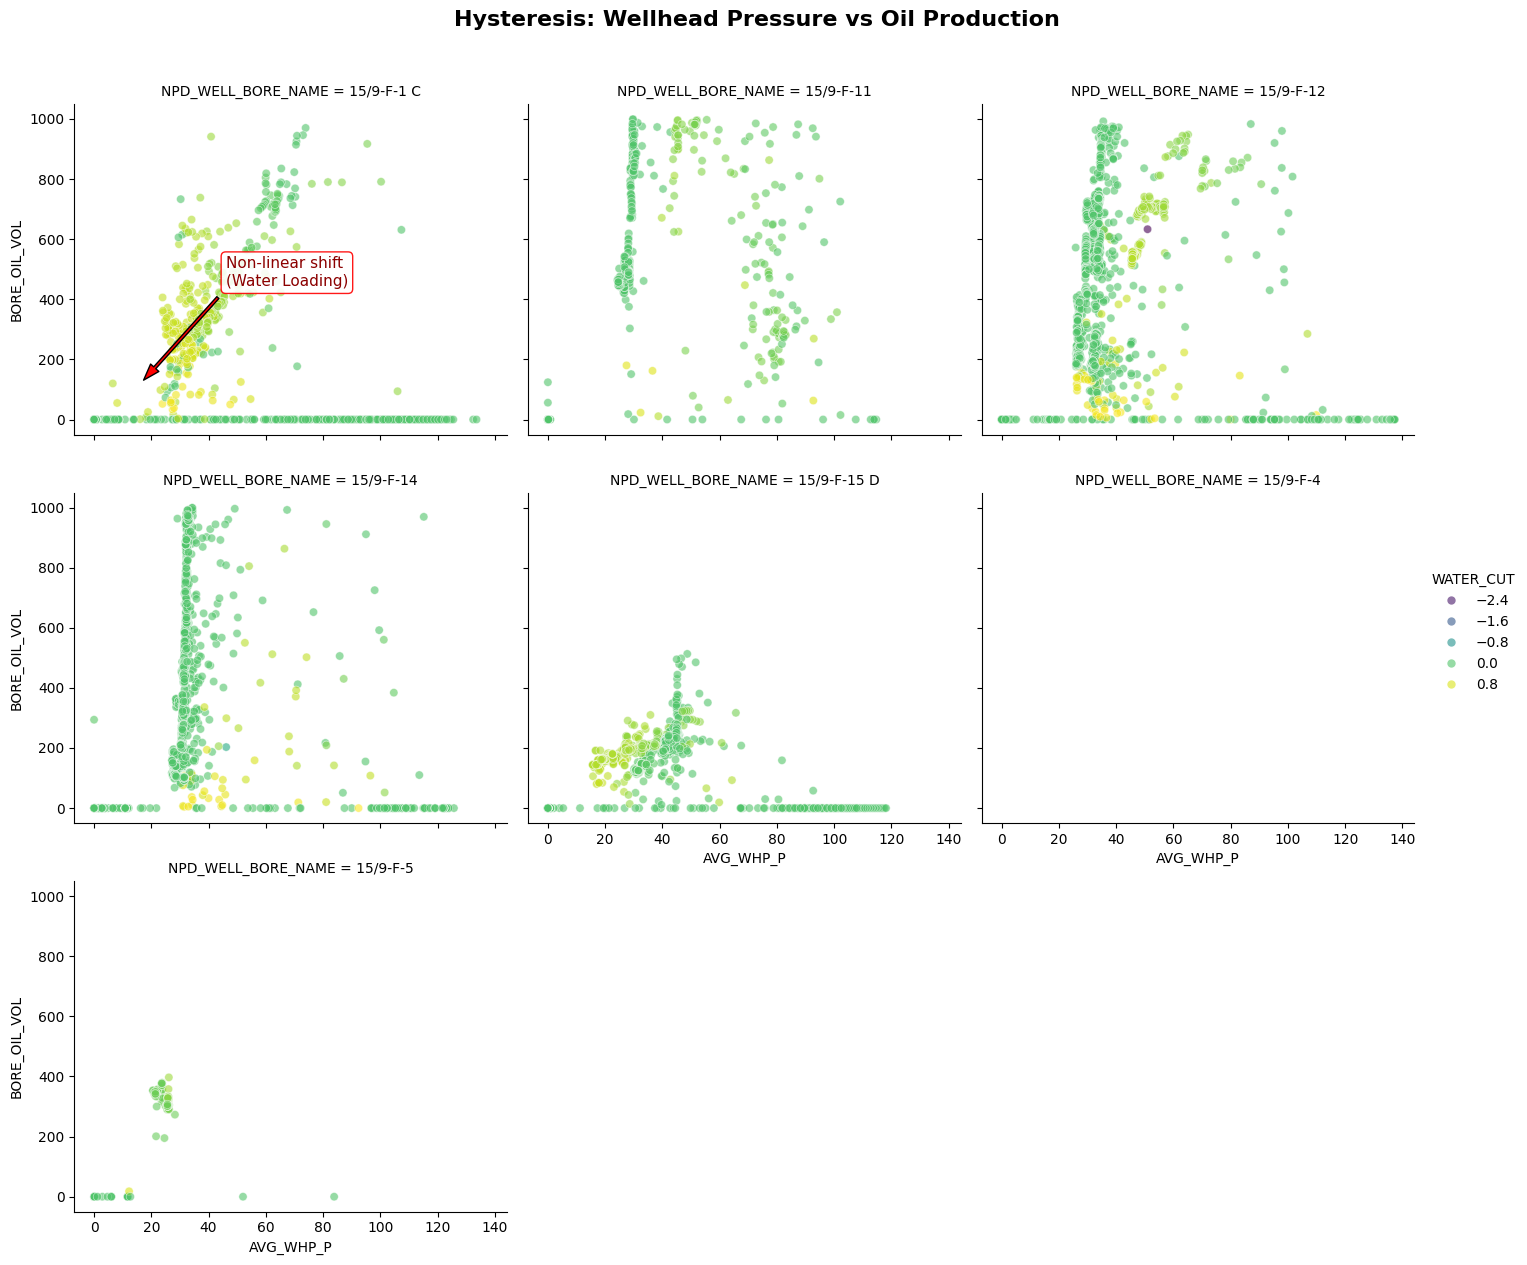

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Ensure required columns are numeric to prevent TypeErrors during math/plotting
# (errors='coerce' will turn any completely invalid text into NaN)
for col in ['BORE_WAT_VOL', 'BORE_OIL_VOL', 'AVG_WHP_P']:
    clean_daily_df[col] = pd.to_numeric(clean_daily_df[col], errors='coerce')

# 1. Create the Water Cut Feature
# Water Cut = Water Volume / Total Liquid Volume (Water + Oil)
# i use .fillna(0) to handle any division-by-zero errors on days the well was shut in.
clean_daily_df['WATER_CUT'] = clean_daily_df['BORE_WAT_VOL'] / (clean_daily_df['BORE_WAT_VOL'] + clean_daily_df['BORE_OIL_VOL'])
clean_daily_df['WATER_CUT'] = clean_daily_df['WATER_CUT'].fillna(0)

# 2. Construct the multi-panel cross-plot using Seaborn
# relplot automatically creates a FacetGrid (multi-panel) based on the 'col' argument
g = sns.relplot(
    data=clean_daily_df,
    x='AVG_WHP_P',
    y='BORE_OIL_VOL',
    col='NPD_WELL_BORE_NAME', # Creates a separate plot for each well
    col_wrap=3,               # Wraps to a new row after 3 plots
    hue='WATER_CUT',          # Colors the markers based on our new feature!
    palette='viridis',        # Dark purple = Low Water Cut, Yellow = High Water Cut.
    alpha=0.6,
    height=4,
    aspect=1.2
)

# Add a main title to the figure
g.fig.suptitle('Hysteresis: Wellhead Pressure vs Oil Production', y=1.05, fontsize=16, fontweight='bold')

# 3. Annotate the plot to highlight the physical regime change
# to shpw the first subplot (axes[0]) and draw an arrow pointing to the
# lower-left region where pressure is behaving erratically due to heavy water.
first_ax = g.axes[0]

first_ax.annotate(
    'Non-linear shift\n(Water Loading)',
    xy=(0.15, 0.15),           # Arrow points here (relative coordinates inside the box)
    xycoords='axes fraction',
    xytext=(0.35, 0.45),       # Text sits here
    textcoords='axes fraction',
    arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
    fontsize=11,
    color='darkred',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white", alpha=0.9)
)

# Display the plot
plt.show()

PHASE 4:Interactive Feature Space Evaluation Dashboard (Plotly)

Task 4.1: Multi-Dimensional Feature Interaction Mapping

In [ ]:
import plotly.express as px

# Isolate data for a specific well, using the logic from your Pandas notebook
well_name = '15/9-F-1 C'
subset = clean_daily_df[clean_daily_df['NPD_WELL_BORE_NAME'] == well_name]

# i use the features engineered in Phase 2 and 3 on the filtered subset

fig = px.scatter_3d(
    subset,
    x='Drawdown_Proxy',           # Pressure Drop (from Task 2.2)
    y='AVG_CHOKE_SIZE_P',         # Choke Size
    z='Choke_Volatility_Index',   # Transient Regime Flag (from Task 2.3)
    color='BORE_OIL_VOL',         # Target Variable (Oil Production)
    size='WATER_CUT',             # Size based on Water Cut (from Task 3.1)
    color_continuous_scale='Viridis',
    opacity=0.7,
    title=f'Interactive 3D Feature Space Evaluation - Well {well_name}',
    labels={
        'Drawdown_Proxy': 'Pressure Drop (Drawdown Proxy)',
        'AVG_CHOKE_SIZE_P': 'Choke Size (%)',
        'Choke_Volatility_Index': 'Choke Volatility Index',
        'BORE_OIL_VOL': 'Oil Volume (Sm3/day)',
        'WATER_CUT': 'Water Cut'
    }
)

# i added a minimum size to the markers so days with 0% water cut don't disappear completely
fig.update_traces(marker=dict(sizemin=3))

# Display the interactive 3D plot
fig.show()